# W4A1 — World Happiness Dataset

---
### Steps
1. Load the data and look at basic info  
2. Clean missing values  
3. Find and remove outliers (IQR first; simple z-score if IQR finds nothing)  
4. Make charts with the cleaned data  
5. Short summary of what the charts show


## 1. Setup — Libraries
We use **pandas** for tables, **matplotlib** and **seaborn** for plots. **NumPy** helps with math.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit nicer and readable
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

Matplotlib is building the font cache; this may take a moment.


## 2. Load the data
The CSV file is in the same folder as this notebook.

In [2]:
df_raw = pd.read_csv("world_happiness_dataset.csv")
df_raw.head(10)

,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10
5,Netherlands,6.41,0.87,0.54,72.6,0.45,0.38,0.36
6,Canada,7.34,0.60,0.46,49.6,1.00,0.07,0.12
7,New Zealand,3.87,0.61,0.57,41.3,0.66,0.26,0.84
8,Australia,5.31,1.43,0.78,53.2,0.36,0.27,0.80
9,Sweden,3.63,1.16,0.62,51.2,0.33,0.57,0.77


In [3]:
print("Shape (rows, columns):", df_raw.shape)
print("\nColumn types:")
print(df_raw.dtypes)
print("\nBasic numbers (numeric columns):")
df_raw.describe()

Shape (rows, columns): (20, 8)

Column types:
Country                       object
Happiness_Score              float64
GDP_per_Capita               float64
Social_Support               float64
Healthy_Life_Expectancy      float64
Freedom_to_Make_Choices      float64
Generosity                   float64
Perceptions_of_Corruption    float64
dtype: object

Basic numbers (numeric columns):


,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,5.171500,1.149000,0.624000,62.290000,0.661000,0.303500,0.503500
std,1.250715,0.304785,0.150382,12.332708,0.227617,0.171196,0.277532
min,3.530000,0.600000,0.430000,41.300000,0.330000,0.010000,0.100000
25%,4.237500,0.907500,0.522500,51.175000,0.472500,0.160000,0.192500
50%,4.995000,1.170000,0.570000,61.350000,0.665000,0.310000,0.525000
75%,6.260000,1.395000,0.772500,73.300000,0.862500,0.415000,0.732500
max,7.340000,1.570000,0.960000,81.600000,1.000000,0.570000,0.860000


## 3. Missing values — check and fix
**Step 3a — Count missing values.**  
We count `NaN` (empty cells) per column.

**Step 3b — What we do.**  
- If there are missing numbers, we fill them with the **median** of that column.  
- The median is less sensitive to very high or low values than the mean.  
- Country names cannot be guessed; if `Country` were missing, we would **drop** that row.

Here we only show the code. The result depends on your file.

In [4]:
missing_per_col = df_raw.isna().sum()
print("Missing values per column:")
print(missing_per_col)
print("\nTotal missing cells:", df_raw.isna().sum().sum())

Missing values per column:
Country                      0
Happiness_Score              0
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom_to_Make_Choices      0
Generosity                   0
Perceptions_of_Corruption    0
dtype: int64

Total missing cells: 0


In [5]:
df = df_raw.copy()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    if df[col].isna().any():
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"Filled missing in '{col}' with median = {med:.4f}")

if df["Country"].isna().any():
    before = len(df)
    df = df.dropna(subset=["Country"])
    print(f"Dropped {before - len(df)} rows with missing country name.")

print("\nAfter missing-value step — any NaN left?", df.isna().sum().sum())


After missing-value step — any NaN left? 0


## 4. Outliers — find and remove

**Method A — IQR** (how box plots define “usual” range):  
For each numeric column we use Q1 (25%), Q3 (75%), IQR = Q3 − Q1.  
- Lower fence = Q1 − 1.5 × IQR  
- Upper fence = Q3 + 1.5 × IQR  
Any value outside the fences is flagged for that column.

**Method B — Z-score** (only if IQR finds nothing useful):  
With **small datasets**, IQR flags can be rare. Then we flag a value when **|z| > 2**  
(`z` = how many standard deviations it is from the mean). That is simple and easy to explain.

**Row rule:** We remove a country if it is flagged in **any** numeric column **by either** method.

First we plot **box plots** to eyeball spread and extremes.

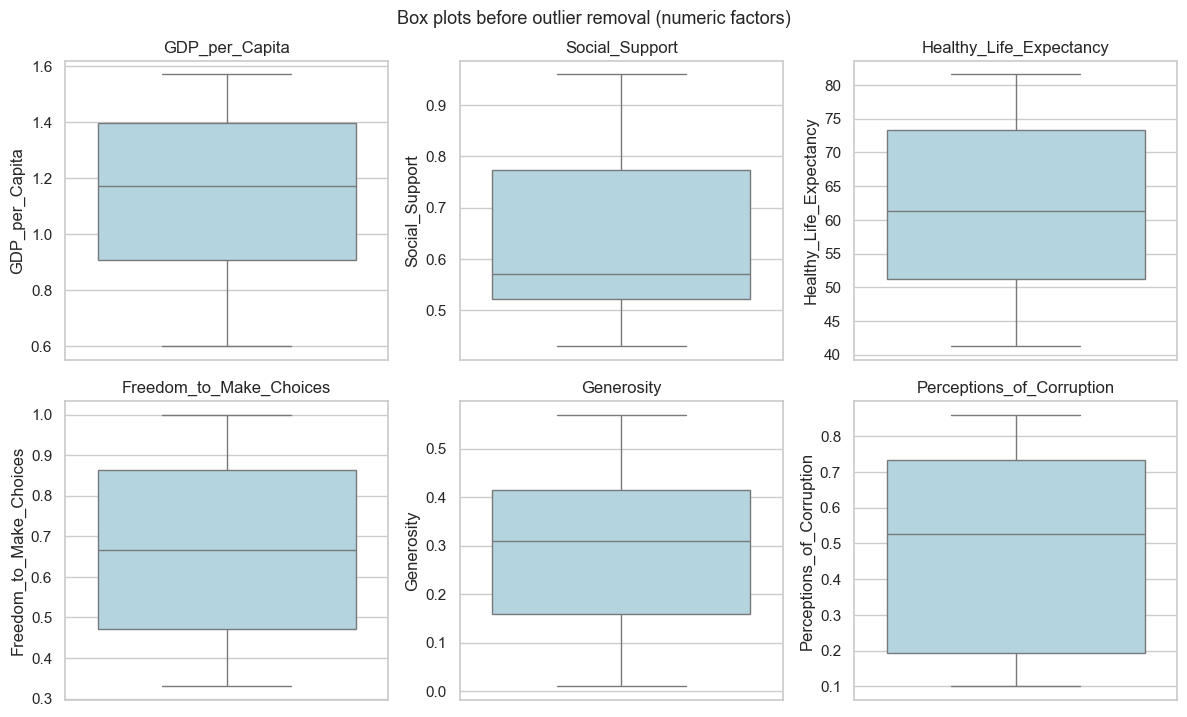

In [6]:
plot_cols = [c for c in num_cols if c != "Happiness_Score"]  # keep plot readable; add happiness in next chart
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for i, col in enumerate(plot_cols[:6]):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col)
plt.tight_layout()
plt.suptitle("Box plots before outlier removal (numeric factors)", y=1.02, fontsize=13)
plt.show()

In [7]:
def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return (series < low) | (series > high)


def z_outlier_mask(series: pd.Series, z_max: float = 2.0) -> pd.Series:
    sigma = series.std(ddof=0)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series(False, index=series.index)
    z = (series - series.mean()) / sigma
    return z.abs() > z_max


flag_iqr = pd.DataFrame(False, index=df.index, columns=num_cols)
flag_z = pd.DataFrame(False, index=df.index, columns=num_cols)
for col in num_cols:
    flag_iqr[col] = iqr_outlier_mask(df[col])
    flag_z[col] = z_outlier_mask(df[col], z_max=2.0)

rows_iqr = flag_iqr.any(axis=1)
if rows_iqr.any():
    outlier_flags = flag_iqr.copy()
    print("Using IQR flags only (IQR flagged at least one row).")
else:
    # Small datasets: IQR can miss extremes; z-score adds a simple second check.
    outlier_flags = flag_iqr | flag_z
    print("IQR flagged no rows. We combine with z-score (|z| > 2) to flag unusual values.")

rows_with_any = outlier_flags.any(axis=1)
flagged_countries = df.loc[rows_with_any, "Country"].tolist()
print("\nCountries flagged by the rule we actually use:")
print(flagged_countries if flagged_countries else "(none)")

detail = pd.concat([df[["Country"]], flag_iqr.add_prefix("iqr_"), flag_z.add_prefix("z_")], axis=1)
detail["used_for_drop"] = rows_with_any
print("\nFlags for countries we remove used_for_drop=True (iqr_/z_ show each method):")
print(detail[detail["used_for_drop"]].to_string())


IQR flagged no rows. We combine with z-score (|z| > 2) to flag unusual values.

Countries flagged by the rule we actually use:
['France']

Flags for countries we remove used_for_drop=True (iqr_/z_ show each method):
   Country  iqr_Happiness_Score  iqr_GDP_per_Capita  iqr_Social_Support  iqr_Healthy_Life_Expectancy  iqr_Freedom_to_Make_Choices  iqr_Generosity  iqr_Perceptions_of_Corruption  z_Happiness_Score  z_GDP_per_Capita  z_Social_Support  z_Healthy_Life_Expectancy  z_Freedom_to_Make_Choices  z_Generosity  z_Perceptions_of_Corruption  used_for_drop
13  France                False               False               False                        False                        False           False                          False              False             False              True                      False                      False         False                        False           True


In [8]:
df_clean = df.loc[~rows_with_any].reset_index(drop=True)
print("Rows before:", len(df), "| after removing outlier rows:", len(df_clean))
df_clean.head()

Rows before: 20 | after removing outlier rows: 19


,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10


*If **no** rows are removed, either your data is smooth or raise the z-score bar (try `z_max=2.5`). If rows are removed, all charts below use **`df_clean`**. The steps above are still the full workflow.*

---
## 5. Visualizations (cleaned data)
We use **`df_clean`**. Simple charts that answer easy questions:

### 5a. Bar chart — Happiness score by country
Countries are sorted from high to low score.

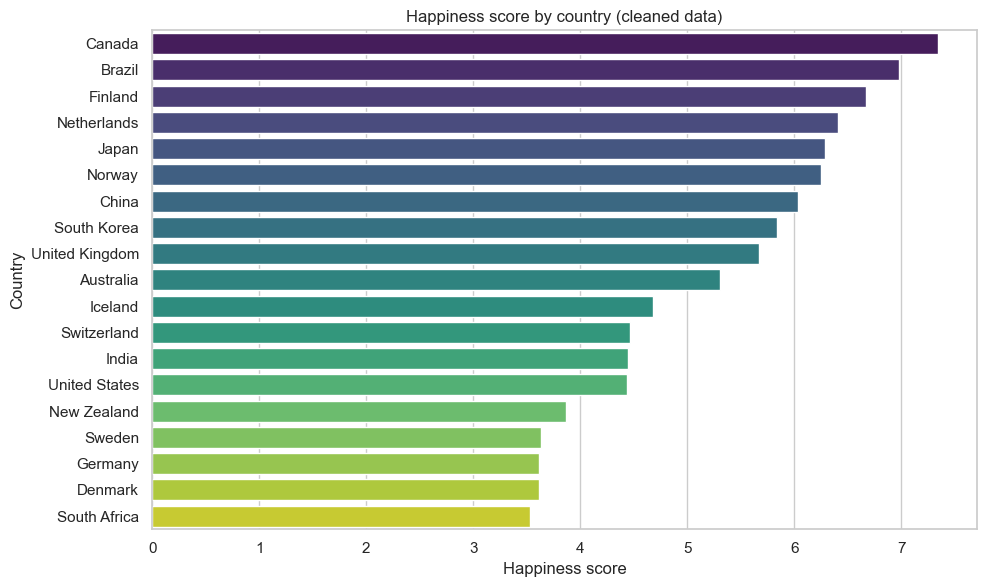

In [9]:
order = df_clean.sort_values("Happiness_Score", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=order, x="Happiness_Score", y="Country", hue="Country", palette="viridis", legend=False)
plt.title("Happiness score by country (cleaned data)")
plt.xlabel("Happiness score")
plt.tight_layout()
plt.show()

### 5b. Scatter plot — GDP per capita vs happiness
We check whether richer countries tend to report higher happiness (we only **see** a pattern here, not a proof of cause).

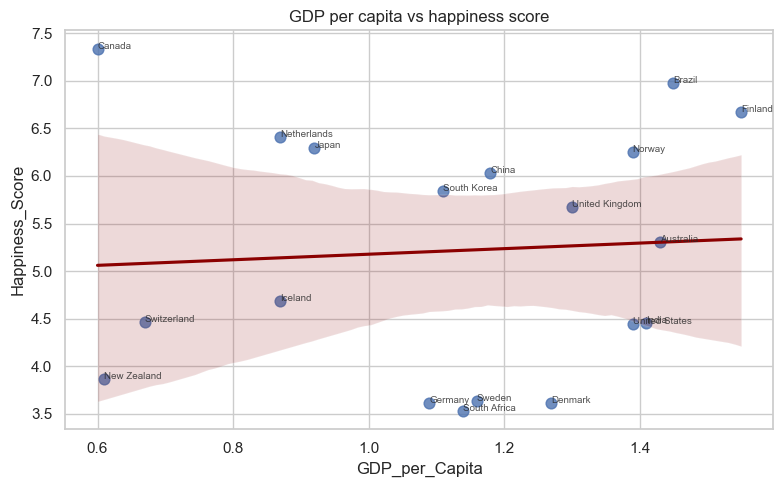

In [10]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_clean,
    x="GDP_per_Capita",
    y="Happiness_Score",
    scatter_kws={"s": 60},
    line_kws={"color": "darkred"},
)
for _, row in df_clean.iterrows():
    plt.annotate(row["Country"], (row["GDP_per_Capita"], row["Happiness_Score"]), fontsize=7, alpha=0.8)
plt.title("GDP per capita vs happiness score")
plt.tight_layout()
plt.show()

### 5c. Correlation heatmap
Numbers near **+1** mean two columns go up together. Near **−1** means one goes up when the other goes down. Near **0** means weak link in a straight line.

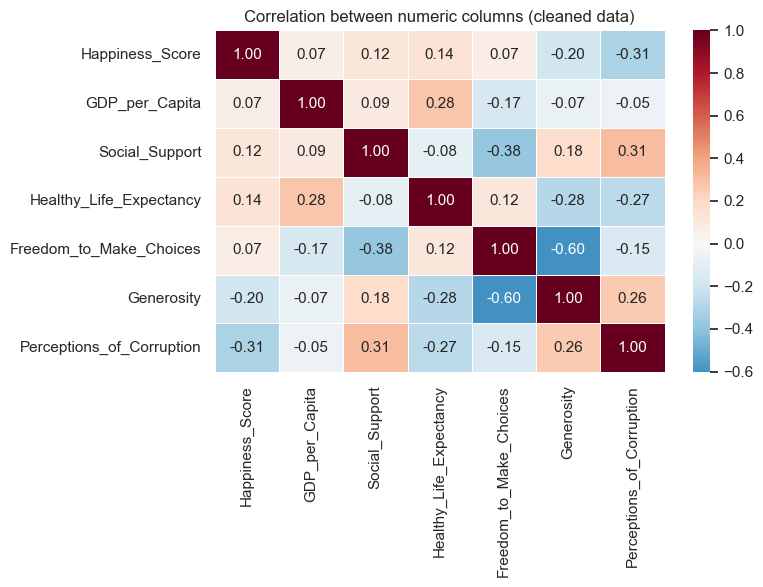

In [11]:
corr = df_clean[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Correlation between numeric columns (cleaned data)")
plt.tight_layout()
plt.show()

### 5d. Pair plot (optional quick view)
Shows pairwise relationships for a few columns. Skip if too busy on screen.

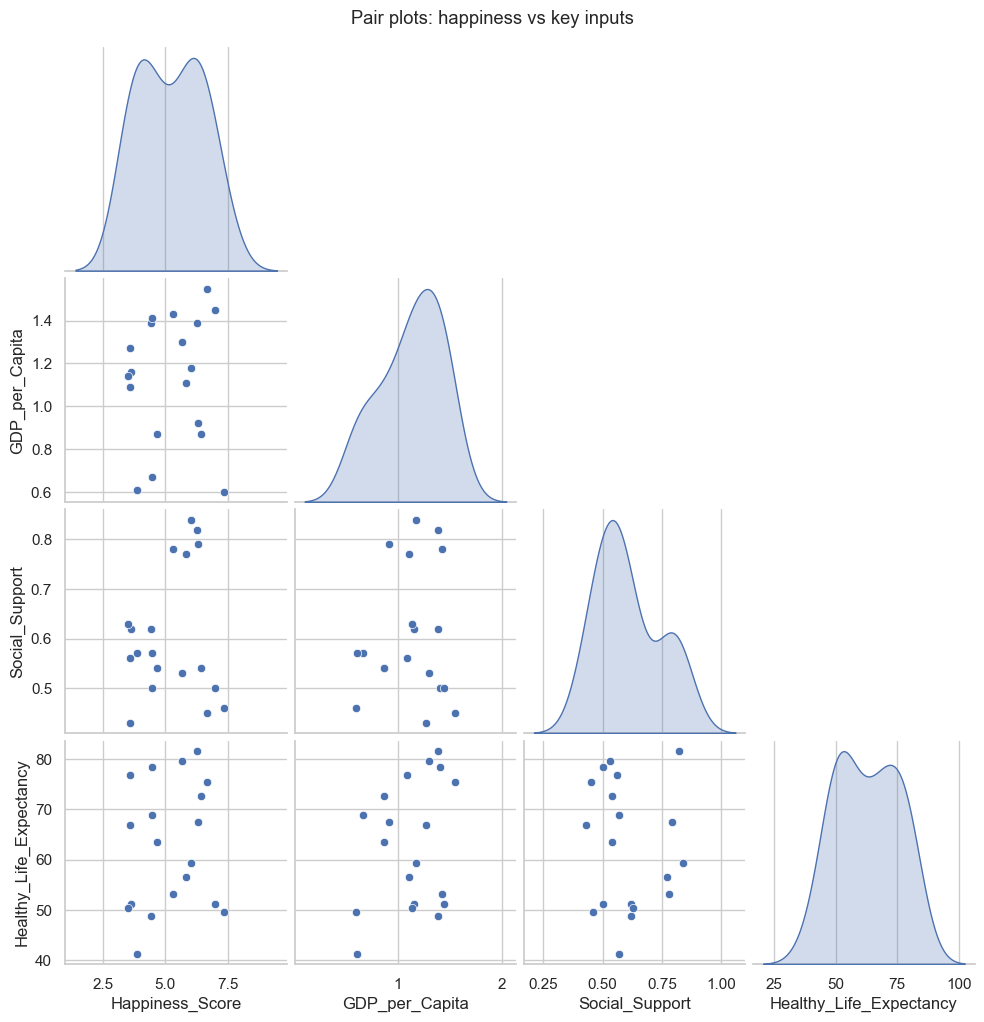

In [12]:
pair_cols = ["Happiness_Score", "GDP_per_Capita", "Social_Support", "Healthy_Life_Expectancy"]
sns.pairplot(df_clean[pair_cols], corner=True, diag_kind="kde")
plt.suptitle("Pair plots: happiness vs key inputs", y=1.02)
plt.show()

---
## 6. Summary of findings (from the charts)

Short points in plain English:

1. **Rankings in our file.** The bar chart sorts countries using `Happiness_Score` after cleaning. Here the scores stretch from roughly **3.5** up to **7.3**. **Canada** and **Brazil** score highest; **South Africa**, **Denmark**, and **New Zealand** are among the lowest. **This mirrors the spreadsheet only** — how we plotted, not guesswork.

2. **GDP vs happiness.** The scatter plot draws a fitted line. Countries **above** the line look happier than the line predicts from GDP; countries **below** look less happy. We only see **a relationship in these numbers**. It does **not** prove that richer people or richer countries automatically feel happier.

3. **Correlations.** The heatmap shows how strongly columns move together. Read strong colors as **“in this dataset, these two scores tend to rise or fall together”**. The pair plots support the same story. Neither chart proves deep real-world causation.

4. **Cleaning (short recap).** The raw file had **no missing entries**. Box plots helped us inspect spread. **IQR** flagged no rows on this tiny table, so we added a simple **z-score** rule (|z| > 2) and **removed one country** flagged that way (**France**) before plotting. Twenty rows dropped to nineteen (`df_clean`).

5. **Important insight — data vs reality.** Some numbers clash with well-known facts. Example: **New Zealand** appears fairly **unhappy** in this CSV, yet common World Happiness Reports list **New Zealand** near **the top**. **Healthy life expectancy** for **Canada** and **New Zealand** also looks unrealistically low in this dataset for rich countries with strong health systems. So our plots are **truthful outputs of this assignment file**, but **the assignment file itself may not match reality or official statistics**. Use the visuals to show workflow and reasoning, **not as a final verdict on real countries.**
